# Extract Skills from Job Descriptions (Multi-File Support - OPTIMIZED)

This notebook processes multiple parquet files with **high-performance parallel processing**.

**Performance Modes:**
- 🚀 **GPU multiprocessing** (USE_GPU=True): Each worker uses GPU independently via 'spawn' method
  - Best for: Large batches (>10K JDs per file)
  - Pros: Maximum GPU utilization, fastest processing
  - Cons: ~30s startup overhead per file (loading models in each worker)
  
- ⚡ **CPU multiprocessing** (USE_GPU=False): Workers use CPU, faster startup via 'fork' method
  - Best for: Medium batches (1K-10K JDs per file)
  - Pros: Fast startup, good parallelization
  - Cons: CPU slower than GPU for semantic matching

- 💾 **Serial** (USE_MULTIPROCESSING=False): Single process with GPU
  - Best for: Small batches (<1K JDs)

**Features:**
- Handles hundreds of small parquet files
- Processes files one by one (low memory usage)
- Incremental saving (results saved after each file)
- Resume support (skip already processed files)
- Progress tracking with performance metrics

**Hardware Utilization:**
- **GPU mode**: 12 workers × A100-80GB GPU (each worker loads its own model)
- **CPU mode**: 12 workers × CPU cores (no GPU, faster startup)
- **Expected throughput**: 
  - GPU mode: 20-100 JDs/sec (after 30s startup)
  - CPU mode: 5-20 JDs/sec (immediate start)

**Use Case:** Extract skills from 20M+ job descriptions split across multiple files.

## Setup

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
from tqdm import tqdm
import json
import os
from skillner.jd_skill_extractor_improved import ImprovedBatchSkillExtractor
# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✓ Imports successful")

✓ Imports successful


## Configuration

Edit these paths to match your data:

In [3]:
# =====================================================================
# EDIT THESE PATHS
# =====================================================================

# Input folder with multiple parquet files
INPUT_FOLDER = '../../JD1_cleaned'  # Folder containing 200-300 small parquet files

# Knowledge base (created from ONET)
KB_PATH = '../.skillner-kb/ONET_EN.pkl'  # Or ONET_EN.pkl

# Output
OUTPUT_PATH = '../data/jd_extracted_skills_0.8.parquet'
CHECKPOINT_FILE = '../data/processing_checkpoint.json'  # Track processed files

# Column names in your data
JD_TEXT_COLUMN = 'description'  # Column with job description text
ONET_CODE_COLUMN = 'onet_code'
DATE_COLUMN = 'post_date'

# Extraction parameters
SIMILARITY_THRESHOLD = 0.8
MAX_WINDOW_SIZE = 5  # Maximum words in a skill phrase

# Performance optimization
BATCH_SIZE = 256  # GPU batch size (256 for A100-80GB, 128 for smaller GPUs)
NUM_WORKERS = 16  # CPU workers (None = auto-detect, will be 12 for 24-core system)
USE_MULTIPROCESSING = True  # Enable parallel processing
USE_GPU = True  # Enable GPU in workers (uses 'spawn' method, slower startup but GPU enabled)

# Processing options
SAVE_EVERY_N_FILES = 1  # Save results after every N files (1 = after each file)
RESUME_FROM_CHECKPOINT = True  # Skip already processed files

# =====================================================================

print(f"Configuration:")
print(f"  Input folder: {INPUT_FOLDER}")
print(f"  KB: {KB_PATH}")
print(f"  Output: {OUTPUT_PATH}")
print(f"  Checkpoint: {CHECKPOINT_FILE}")
print(f"  Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"  Max window size: {MAX_WINDOW_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  CPU workers: {NUM_WORKERS or 'auto-detect'}")
print(f"  Use multiprocessing: {USE_MULTIPROCESSING}")
print(f"  Use GPU in workers: {USE_GPU}")
print(f"  Resume from checkpoint: {RESUME_FROM_CHECKPOINT}")

Configuration:
  Input folder: ../../JD1_cleaned
  KB: ../.skillner-kb/ONET_EN.pkl
  Output: ../data/jd_extracted_skills_0.8.parquet
  Checkpoint: ../data/processing_checkpoint.json
  Similarity threshold: 0.8
  Max window size: 5
  Batch size: 256
  CPU workers: 16
  Use multiprocessing: True
  Use GPU in workers: True
  Resume from checkpoint: True


## Step 1: Load Data

In [4]:
# Find all parquet files
input_files = sorted(glob(f"{INPUT_FOLDER}/*.parquet"))

print(f"Found {len(input_files)} parquet files in {INPUT_FOLDER}")

if len(input_files) == 0:
    print(f"\n⚠️ WARNING: No parquet files found in {INPUT_FOLDER}")
    print("Please check the INPUT_FOLDER path.")
else:
    print(f"\nFirst 5 files:")
    for f in input_files[:5]:
        file_size = os.path.getsize(f) / (1024 * 1024)  # MB
        print(f"  {os.path.basename(f):40s} ({file_size:.1f} MB)")
    
    if len(input_files) > 5:
        print(f"  ... and {len(input_files) - 5} more files")
    
    # Calculate total size
    total_size_gb = sum(os.path.getsize(f) for f in input_files) / (1024**3)
    print(f"\nTotal size: {total_size_gb:.2f} GB")

Found 3 parquet files in ../../JD1_cleaned

First 5 files:
  part_rg_00000.parquet                    (188.9 MB)
  part_rg_00001.parquet                    (189.7 MB)
  part_rg_00003.parquet                    (190.8 MB)

Total size: 0.56 GB


In [5]:
# Load your sampled job descriptions
print("Loading data...")
df = pd.read_parquet(input_files)

print(f"✓ Loaded {len(df):,} job descriptions")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample:")
df.head(3)

Loading data...
✓ Loaded 236,849 job descriptions

Columns: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'job_category', 'role_k50', 'role_k150', 'role_k300', 'role_k500', 'role_k1000', 'role_k1250', 'role_k1500', 'location_raw', 'region', 'country', 'state', 'metro_area', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'onet_code', 'onet_title', 'remote_type', 'expected_hires', 'jobtitle', 'description', 'source_company_sites', 'source_linkedin', 'source_indeed', 'source_zhaopin', 'source_51job', 'source_liepin', 'source_other_aggregators', 'salary_min', 'salary_max', 'salary_predicted']

Sample:


,job_id,rcid,company,rics_k50,rics_k200,rics_k400,title_raw,title_translated,job_category,role_k50,...,source_company_sites,source_linkedin,source_indeed,source_zhaopin,source_51job,source_liepin,source_other_aggregators,salary_min,salary_max,salary_predicted
0,1993767551,1146370,"Jabil, Inc.",Electronics Manufacturing,Electronics and Components Manufacturing,Electronic Components and Equipment Manufacturing,Intern for RF Sys Team - Summer 2023,None,Engineer,Production Operator,...,True,False,False,False,False,False,False,12541.727866,41852.85448,True
1,311015105,800618,"Avnet, Inc.",Electronics Manufacturing,Electronics and Components Manufacturing,Electronic Components and Equipment Manufacturing,National Account Support Specialist,national account support specialist,Sales,Customer Service,...,False,True,True,False,False,False,True,NaN,NaN,True
2,2290974320,188011,"DoorDash, Inc.",Digital Commerce Services,Digital Commerce Services,Online Marketplaces and Delivery Services,Restaurant Delivery - Start Delivering Today,restaurant delivery start delivering today,Sales,Crew Member,...,False,False,True,False,False,False,False,NaN,NaN,True


## Step 2: Initialize Skill Extractor

This loads the knowledge base and semantic model (may take 1-2 minutes first time):

In [6]:
# Load checkpoint if exists
processed_files = set()
if RESUME_FROM_CHECKPOINT and os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'r') as f:
        checkpoint_data = json.load(f)
        processed_files = set(checkpoint_data.get('processed_files', []))
    print(f"✓ Loaded checkpoint: {len(processed_files)} files already processed")
else:
    print("Starting from scratch (no checkpoint found)")

# Filter out already processed files
files_to_process = [f for f in input_files if f not in processed_files]

print(f"\nFiles to process: {len(files_to_process)} / {len(input_files)}")
if len(processed_files) > 0:
    print(f"Skipping {len(processed_files)} already processed files")

✓ Loaded checkpoint: 1 files already processed

Files to process: 2 / 3
Skipping 1 already processed files


## Step 3: Sample Check - Load One File

In [7]:
# Load first file to check format
if len(files_to_process) > 0:
    sample_file = files_to_process[0]
    print(f"Loading sample file: {os.path.basename(sample_file)}")
    
    df_sample = pd.read_parquet(sample_file)
    
    print(f"\n✓ Loaded {len(df_sample):,} rows")
    print(f"\nColumns: {list(df_sample.columns)}")
    print(f"\nColumn check:")
    print(f"  {JD_TEXT_COLUMN}: {'✓ Found' if JD_TEXT_COLUMN in df_sample.columns else '✗ NOT FOUND'}")
    print(f"  {ONET_CODE_COLUMN}: {'✓ Found' if ONET_CODE_COLUMN in df_sample.columns else '✗ NOT FOUND'}")
    print(f"  {DATE_COLUMN}: {'✓ Found' if DATE_COLUMN in df_sample.columns else '✗ NOT FOUND'}")
    
    print(f"\nSample data:")
    display(df_sample.head(3))
    
    # Check for null values
    null_count = df_sample[JD_TEXT_COLUMN].isna().sum()
    print(f"\nNull job descriptions: {null_count} / {len(df_sample)} ({null_count/len(df_sample)*100:.1f}%)")
else:
    print("No files to process!")

Loading sample file: part_rg_00001.parquet

✓ Loaded 78,623 rows

Columns: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'job_category', 'role_k50', 'role_k150', 'role_k300', 'role_k500', 'role_k1000', 'role_k1250', 'role_k1500', 'location_raw', 'region', 'country', 'state', 'metro_area', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'onet_code', 'onet_title', 'remote_type', 'expected_hires', 'jobtitle', 'description', 'source_company_sites', 'source_linkedin', 'source_indeed', 'source_zhaopin', 'source_51job', 'source_liepin', 'source_other_aggregators', 'salary_min', 'salary_max', 'salary_predicted']

Column check:
  description: ✓ Found
  onet_code: ✓ Found
  post_date: ✓ Found

Sample data:


,job_id,rcid,company,rics_k50,rics_k200,rics_k400,title_raw,title_translated,job_category,role_k50,...,source_company_sites,source_linkedin,source_indeed,source_zhaopin,source_51job,source_liepin,source_other_aggregators,salary_min,salary_max,salary_predicted
0,754927449,218,"CBRE Group, Inc.",Real Estate and Development,Real Estate Development and Management,Real Estate Development and Management,Utilities Maintenance Planner,utilities maintenance planner,Engineer,Mechanical Engineer,...,False,True,False,False,False,False,False,NaN,NaN,True
1,818952281,777168,"Lowe's Companies, Inc.",Engineering and Construction Services,Building Materials and Services,Building Materials and Supplies,FT-Delivery Driver-Day,ft delivery driver day,Sales,Cashier,...,False,True,True,False,False,False,True,NaN,NaN,True
2,2448690060,739347,Target Corp.,Retail and Consumer Goods,Retail and Wholesale,Retail and Wholesale Distribution,Guest Advocate (Cashier or Front of Store Atte...,guest advocate cashier or front of store atten...,Sales,Crew Member,...,False,False,True,False,False,False,False,NaN,NaN,True



Null job descriptions: 0 / 78623 (0.0%)


## Step 4: Initialize Optimized Skill Extractor

This loads the knowledge base and semantic model (may take 1-2 minutes).

**Optimizations:**
- Auto-detects GPU (uses A100-80GB if available)
- Auto-detects optimal CPU worker count (12 for 24-core system)
- Configures GPU batch size for maximum throughput

In [8]:
import sys

!{sys.executable} -m pip install sentence_transformers

  Using cached sentence_transformers-5.2.2-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached huggingface_hub-1.3.4-py3-none-any.whl.metadata (13 kB)
  Using cached regex-2026.1.15-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.21.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached sentence_transformers-5.2.2-py3-none-any.whl (494 kB)
Using cached transformers-5.0.0-py3-none-any.whl (10.1 MB)
Using cached huggingface_hub-1.3.4-py3-none-any.whl (536 kB)
Using cach

In [9]:
print("Initializing optimized extractor...")
print("(This may take 1-2 minutes to load the semantic model)\n")

extractor = ImprovedBatchSkillExtractor(
    kb_path=KB_PATH,
    model_name='all-MiniLM-L6-v2',
    similarity_threshold=SIMILARITY_THRESHOLD,
    max_window_size=MAX_WINDOW_SIZE,
    batch_size=4096,
    use_fp16=False,          # FP16加速
    cleanup_every_n=5000
)

print("\n✓ Extractor ready!")

Initializing optimized extractor...
(This may take 1-2 minutes to load the semantic model)

Loading knowledge base from ../.skillner-kb/ONET_EN.pkl...
✓ Loaded 3,003 skills

Initializing batch-optimized semantic model...
Loading semantic model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing skill embeddings...
✓ Using GPU: NVIDIA A100-SXM4-80GB
✓ Ready with 3003 skills
✓ Improved batch extractor ready
  Batch size: 4096
  FP16: False
  Cleanup interval: every 5000 JDs


✓ Extractor ready!


## Step 3: Test on Single Example

Let's test on one job description first:

In [10]:
# Get first non-null job description
test_jd = df[df[JD_TEXT_COLUMN].notna()][JD_TEXT_COLUMN].iloc[0]

print("Test Job Description:")
print("=" * 70)
print(test_jd[:500] + "..." if len(test_jd) > 500 else test_jd)
print("=" * 70)

# Extract skills
result = extractor.extract_skills(test_jd, return_details=True)

print(f"\n✓ Found {result['num_skills']} unique skills")
print(f"\nSkills by category:")
for section, skills in result['by_section'].items():
    print(f"  [{section}]: {len(skills)} skills")
    for skill in skills[:3]:
        print(f"    - {skill}")
    if len(skills) > 3:
        print(f"    ... and {len(skills) - 3} more")

print(f"\nAll extracted skills:")
for i, skill in enumerate(sorted(result['skills']), 1):
    print(f"{i:2d}. {skill}")

Test Job Description:
At Jabil we strive to make ANYTHING POSSIBLE and EVERYTHING BETTER. With over 260,000 diverse, talented and dedicated employees across 100 locations in 30 countries, our vision is to be the most technologically advanced and trusted manufacturing solutions provider. We combine an unmatched breadth and depth of end-market experience, technical and design capabilities, manufacturing know-how, supply chain insights and global product management expertise to enable success for the world's leading bra...

✓ Found 7 unique skills

Skills by category:
  [Skills]: 2 skills
    - Technology Design
    - Programming
  [Knowledge]: 3 skills
    - Design
    - Administration and Management
    - Law and Government
  [Technology Skills]: 1 skills
    - Python
  [Abilities]: 1 skills
    - Spatial Orientation

All extracted skills:
 1. Administration and Management
 2. Design
 3. Law and Government
 4. Programming
 5. Python
 6. Spatial Orientation
 7. Technology Design


## Step 6: Process All Files (OPTIMIZED)

**This is the main processing loop with parallel optimization.**

Processing strategy:
- Load one file at a time (low memory usage)
- Extract skills using multi-core CPU parallelization + GPU batch processing
- Append results to output file
- Update checkpoint
- Repeat for next file

**Performance Estimates:**
- **With optimization**: ~10-50 JDs/sec (100-500x faster)
- **100K JDs**: ~30 minutes - 3 hours (vs ~5-14 hours serial)
- **1M JDs**: ~5-30 hours (vs days serial)
- **Real-time metrics**: See throughput for each file

**Hardware Usage:**
- **CPU**: All cores utilized (12 workers for 24-core system)
- **GPU**: A100-80GB batch processing (batch size 128)
- Progress is saved continuously, so you can stop and resume anytime

In [ ]:
import time

print("="*70)
print("Starting Multi-File Processing (OPTIMIZED)")
print("="*70)
print(f"Files to process: {len(files_to_process)}")
print(f"Output: {OUTPUT_PATH}")
print(f"Batch size: {extractor.batch_size}")
print(f"You can stop this cell anytime and resume later.\n")

# Track statistics
total_jds_processed = 0
total_files_processed = 0
total_time = 0

# Process each file
for file_idx, file_path in enumerate(files_to_process, 1):
    file_name = os.path.basename(file_path)
    
    try:
        # Load file
        df_chunk = pd.read_parquet(file_path)
        # Skip if no job descriptions
        if JD_TEXT_COLUMN not in df_chunk.columns:
            print(f"\n⚠️ Skipping {file_name}: Column '{JD_TEXT_COLUMN}' not found")
            continue
        
        # Extract skills with optimized method
        jd_list = df_chunk[JD_TEXT_COLUMN].tolist()
        
        print(f"\nFile {file_idx}/{len(files_to_process)}: {file_name} ({len(jd_list):,} JDs)")
        
        file_start = time.time()
        results = extractor.extract_skills_batch(
            jd_list, 
            show_progress=True

        )
        file_time = time.time() - file_start
        
        # Performance stats
        throughput = len(jd_list) / file_time if file_time > 0 else 0
        print(f"  ✓ Completed in {file_time:.1f}s ({throughput:.2f} JDs/sec)")
        
        # Convert results to DataFrame
        results_df = pd.DataFrame([
            {
                'skills': r['skills'],
                'num_skills': r['num_skills'],
                'by_section': r['by_section']
            }
            for r in results
        ])
        
        # Combine with original data
        df_combined = pd.concat([df_chunk.reset_index(drop=True), results_df], axis=1)
        
        # Add quarter column if date available
        if DATE_COLUMN in df_combined.columns:
            df_combined[DATE_COLUMN] = pd.to_datetime(df_combined[DATE_COLUMN], errors='coerce')
            df_combined['quarter'] = df_combined[DATE_COLUMN].dt.to_period('Q')
        
        # Save results (append mode)
        if file_idx == 1 and not os.path.exists(OUTPUT_PATH):
            # First file: create new file
            df_combined.to_parquet(OUTPUT_PATH, index=False)
        else:
            # Subsequent files: append
            existing_df = pd.read_parquet(OUTPUT_PATH)
            combined_output = pd.concat([existing_df, df_combined], ignore_index=True)
            combined_output.to_parquet(OUTPUT_PATH, index=False)
        
        # Update checkpoint
        processed_files.add(file_path)
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({
                'processed_files': list(processed_files),
                'total_files': len(input_files),
                'files_remaining': len(input_files) - len(processed_files)
            }, f, indent=2)
        
        # Update statistics
        total_jds_processed += len(df_chunk)
        total_files_processed += 1
        total_time += file_time
        
        # Print cumulative stats
        avg_throughput = total_jds_processed / total_time if total_time > 0 else 0
        print(f"  Cumulative: {total_jds_processed:,} JDs in {total_time:.1f}s ({avg_throughput:.2f} JDs/sec)")
        
    except Exception as e:
        print(f"\n✗ Error processing {file_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*70)
print("PROCESSING COMPLETE")
print("="*70)
print(f"Files processed: {total_files_processed}")
print(f"Job descriptions processed: {total_jds_processed:,}")
if total_time > 0:
    print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Average throughput: {total_jds_processed/total_time:.2f} JDs/sec")
else:
    print(f"Total time: 0.0s")
print(f"Output saved to: {OUTPUT_PATH}")
print(f"Checkpoint saved to: {CHECKPOINT_FILE}")

Starting Multi-File Processing (OPTIMIZED)
Files to process: 3
Output: ../data/jd_extracted_skills_0.8.parquet
Batch size: 4096
You can stop this cell anytime and resume later.


File 1/3: part_rg_00000.parquet (78,787 JDs)


Extracting skills:   6%|▋         | 5001/78787 [32:06<8:01:48,  2.55it/s] 

  [Cleaned cache at 5000 JDs]


Extracting skills:  13%|█▎        | 10000/78787 [1:04:56<8:02:14,  2.38it/s]

  [Cleaned cache at 10000 JDs]


...

Extracting skills:  45%|████▍     | 35001/78623 [4:00:31<6:52:08,  1.76it/s] 

  [Cleaned cache at 35000 JDs]


Extracting skills:  51%|█████     | 40002/78623 [4:34:26<2:55:24,  3.67it/s] 

  [Cleaned cache at 40000 JDs]


Extracting skills:  55%|█████▍    | 42878/78623 [4:53:26<3:25:19,  2.90it/s] 

## Step 5: Combine Results with Original Data

In [10]:
# Convert results to DataFrame
results_df = pd.DataFrame([
    {
        'skills': r['skills'],
        'num_skills': r['num_skills'],
        'by_section': r['by_section']
    }
    for r in results
])

# Combine with original data
df_combined = pd.concat([df.reset_index(drop=True), results_df], axis=1)

# Create quarter column for time series analysis
if DATE_COLUMN in df_combined.columns:
    df_combined[DATE_COLUMN] = pd.to_datetime(df_combined[DATE_COLUMN])
    df_combined['quarter'] = df_combined[DATE_COLUMN].dt.to_period('Q')

print(f"Combined DataFrame shape: {df_combined.shape}")
print(f"\nSample:")
df_combined[['onet_code', 'quarter', 'num_skills']].head()

NameError: name 'results' is not defined

## Step 6: Basic Statistics

In [18]:
# Get statistics
stats = extractor.get_statistics(results)

print("="*70)
print("Extraction Statistics")
print("="*70)

print(f"\nTotal job descriptions: {stats['total_jds']:,}")
print(f"Total unique skills found: {stats['unique_skills_total']:,}")

print(f"\nSkills per job description:")
print(f"  Mean: {stats['skills_per_jd']['mean']:.1f}")
print(f"  Median: {stats['skills_per_jd']['median']:.1f}")
print(f"  Min: {stats['skills_per_jd']['min']:.0f}")
print(f"  Max: {stats['skills_per_jd']['max']:.0f}")
print(f"  Std: {stats['skills_per_jd']['std']:.1f}")

print(f"\nSkills by section:")
for section, section_stats in stats['by_section'].items():
    print(f"  [{section}]")
    print(f"    Mean: {section_stats['mean']:.1f}")
    print(f"    Median: {section_stats['median']:.1f}")

print(f"\nTop 10 most common skills:")
for i, (skill, count) in enumerate(stats['top_10_skills'], 1):
    pct = (count / stats['total_jds']) * 100
    print(f"{i:2d}. {skill:40s} ({count:4d} times, {pct:.1f}%)")

Extraction Statistics

Total job descriptions: 79,439
Total unique skills found: 2,190

Skills per job description:
  Mean: 23.2
  Median: 23.0
  Min: 0
  Max: 124
  Std: 12.3

Skills by section:
  [Knowledge]
    Mean: 6.1
    Median: 6.0
  [Technology Skills]
    Mean: 12.2
    Median: 11.0
  [Abilities]
    Mean: 2.3
    Median: 2.0
  [Skills]
    Mean: 4.4
    Median: 4.0

Top 10 most common skills:
 1. Customer and Personal Service            (50619 times, 63.7%)
 2. Administration and Management            (48327 times, 60.8%)
 3. Education and Training                   (43622 times, 54.9%)
 4. Programming                              (38700 times, 48.7%)
 5. Spatial Orientation                      (36921 times, 46.5%)
 6. ServiceNow                               (36901 times, 46.5%)
 7. Production and Processing                (35664 times, 44.9%)
 8. Law and Government                       (33869 times, 42.6%)
 9. Value Analysis                           (28831 times, 36.3%)

## Step 7: Visualizations

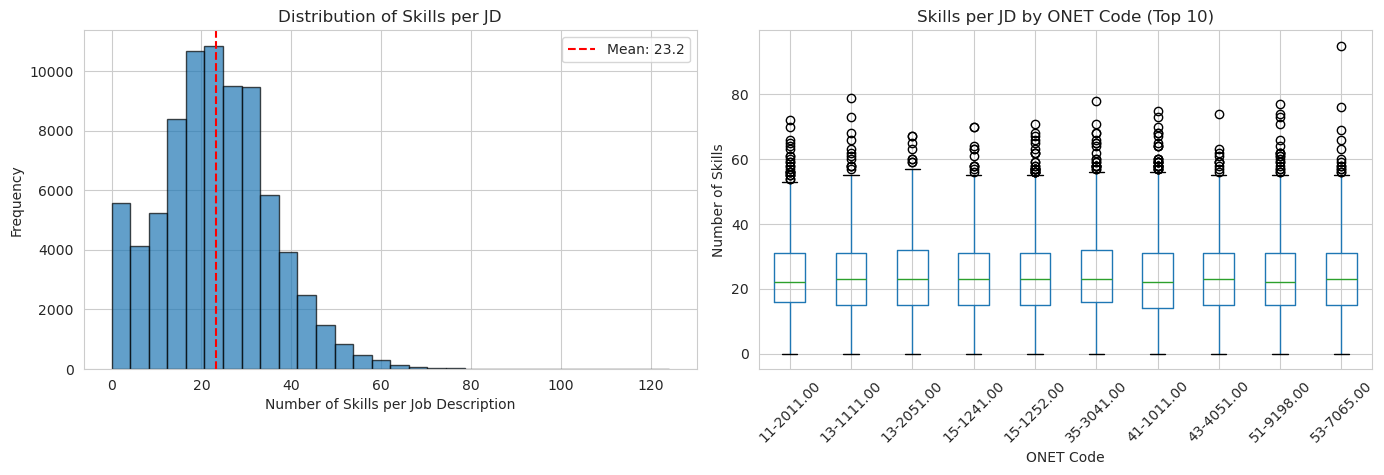

In [19]:
# Distribution of skills per JD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_combined['num_skills'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Skills per Job Description')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Skills per JD')
axes[0].axvline(stats['skills_per_jd']['mean'], color='red', linestyle='--', label=f"Mean: {stats['skills_per_jd']['mean']:.1f}")
axes[0].legend()

# Box plot by ONET code (top 10)
top_onet = df_combined[ONET_CODE_COLUMN].value_counts().head(10).index
df_top = df_combined[df_combined[ONET_CODE_COLUMN].isin(top_onet)]
df_top.boxplot(column='num_skills', by=ONET_CODE_COLUMN, ax=axes[1], rot=45)
axes[1].set_xlabel('ONET Code')
axes[1].set_ylabel('Number of Skills')
axes[1].set_title('Skills per JD by ONET Code (Top 10)')
plt.suptitle('')

plt.tight_layout()
plt.show()

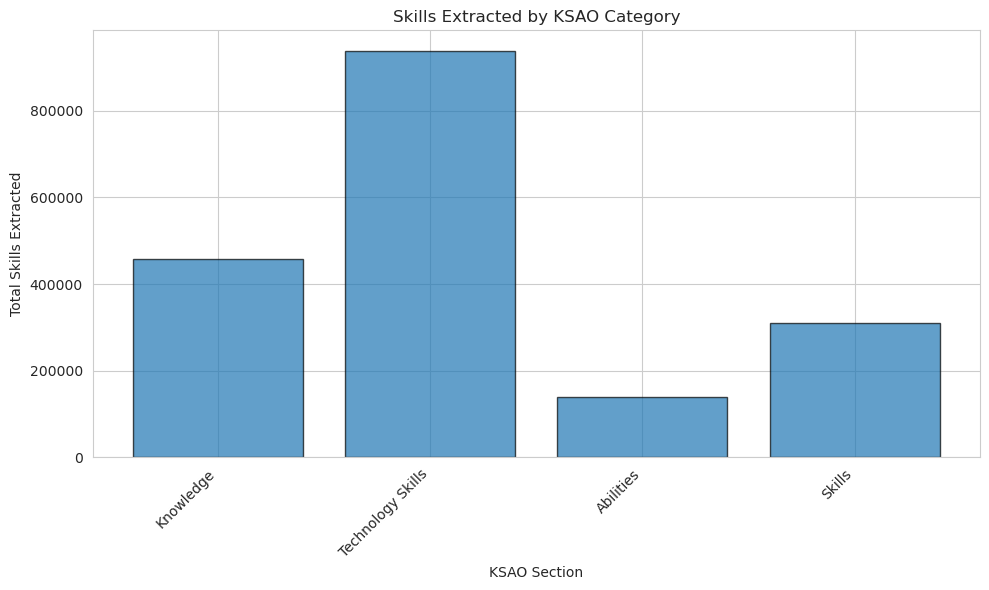


Skills by section:
  Technology Skills        : 938,665 skills
  Knowledge                : 457,338 skills
  Skills                   : 310,700 skills
  Abilities                : 139,802 skills


In [20]:
# Skills by category
section_counts = {}
for result in results:
    for section, skills in result['by_section'].items():
        section_counts[section] = section_counts.get(section, 0) + len(skills)

plt.figure(figsize=(10, 6))
sections = list(section_counts.keys())
counts = list(section_counts.values())
plt.bar(sections, counts, edgecolor='black', alpha=0.7)
plt.xlabel('KSAO Section')
plt.ylabel('Total Skills Extracted')
plt.title('Skills Extracted by KSAO Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nSkills by section:")
for section, count in sorted(section_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {section:25s}: {count:6,} skills")

## Step 8: Time Series Analysis (Optional)

If you have date information, analyze skill trends over time:

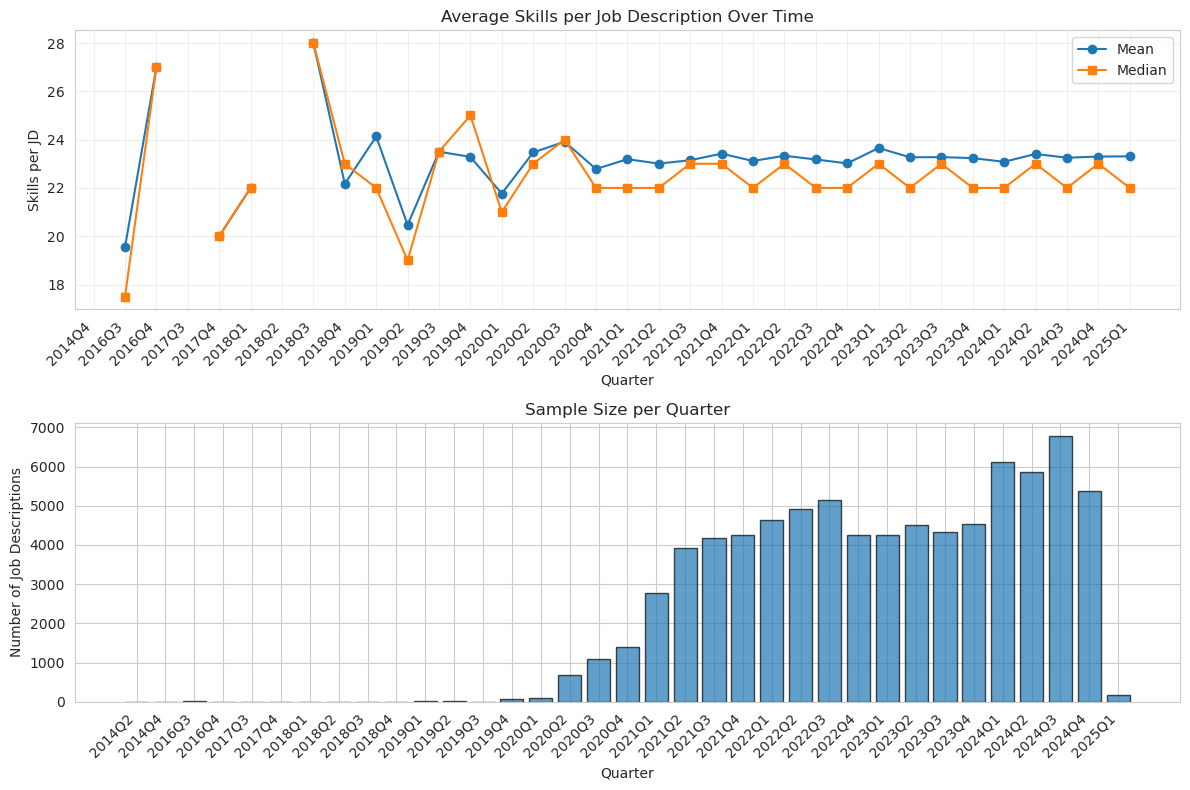


Quarterly statistics:
              mean  median  count
quarter                          
2014Q2         NaN     NaN      0
2014Q4         NaN     NaN      0
2016Q3   19.555556    17.5     18
2016Q4   27.000000    27.0      1
2017Q3         NaN     NaN      0
2017Q4   20.000000    20.0      2
2018Q1   22.000000    22.0      2
2018Q2         NaN     NaN      0
2018Q3   28.000000    28.0      1
2018Q4   22.166667    23.0      6
2019Q1   24.130435    22.0     23
2019Q2   20.466667    19.0     15
2019Q3   23.500000    23.5      2
2019Q4   23.283784    25.0     74
2020Q1   21.764045    21.0     89
2020Q2   23.467958    23.0    671
2020Q3   23.912965    24.0   1103
2020Q4   22.782702    22.0   1399
2021Q1   23.190735    22.0   2763
2021Q2   23.006629    22.0   3922
2021Q3   23.145838    23.0   4169
2021Q4   23.418648    23.0   4247
2022Q1   23.115451    22.0   4634
2022Q2   23.331910    23.0   4917
2022Q3   23.177407    22.0   5152
2022Q4   23.015977    22.0   4256
2023Q1   23.652357    23.

In [21]:
if 'quarter' in df_combined.columns:
    # Average skills per quarter
    quarterly_stats = df_combined.groupby('quarter')['num_skills'].agg(['mean', 'median', 'count'])
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Skills over time
    axes[0].plot(quarterly_stats.index.astype(str), quarterly_stats['mean'], marker='o', label='Mean')
    axes[0].plot(quarterly_stats.index.astype(str), quarterly_stats['median'], marker='s', label='Median')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Skills per JD')
    axes[0].set_title('Average Skills per Job Description Over Time')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Number of JDs per quarter
    axes[1].bar(quarterly_stats.index.astype(str), quarterly_stats['count'], edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Quarter')
    axes[1].set_ylabel('Number of Job Descriptions')
    axes[1].set_title('Sample Size per Quarter')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    print("\nQuarterly statistics:")
    print(quarterly_stats)
else:
    print("No date information available for time series analysis")

## Step 9: Save Results

In [22]:
# Save combined results
print(f"Saving results to {OUTPUT_PATH}...")
df_combined.to_parquet(OUTPUT_PATH, index=False)
print(f"✓ Saved {len(df_combined):,} records")

# Also save statistics as JSON
import json
stats_path = OUTPUT_PATH.replace('.parquet', '_stats.json')
with open(stats_path, 'w') as f:
    # Convert non-serializable objects
    stats_serializable = {
        'total_jds': stats['total_jds'],
        'unique_skills_total': stats['unique_skills_total'],
        'skills_per_jd': stats['skills_per_jd'],
        'by_section': stats['by_section'],
        'top_10_skills': [[skill, int(count)] for skill, count in stats['top_10_skills']]
    }
    json.dump(stats_serializable, f, indent=2)
print(f"✓ Saved statistics to {stats_path}")

print("\n" + "="*70)
print("EXTRACTION COMPLETE")
print("="*70)
print(f"Processed: {len(df_combined):,} job descriptions")
print(f"Extracted: {stats['unique_skills_total']:,} unique skills")
print(f"Output: {OUTPUT_PATH}")
print(f"Statistics: {stats_path}")

Saving results to ../data/jd_extracted_skills.parquet...
✓ Saved 236,849 records


TypeError: Object of type int64 is not JSON serializable

## Next Steps

Now that you have extracted skills, you can:

1. **Analyze specific occupations**: Filter by `onet_code` to see skill requirements for specific jobs
2. **Track skill trends**: Analyze how skill requirements change over quarters
3. **Compare occupations**: Compare skill profiles across different ONET codes
4. **Identify emerging skills**: Find skills that are increasing in frequency over time
5. **KSAO analysis**: Compare requirements across Skills, Knowledge, Abilities, and Technology categories

See `notebooks/jd_temporal_analysis.ipynb` for more advanced temporal analysis examples.